# 04 — Reward Analysis and Component Validation
This notebook validates reward construction from `src.reward`, including component contributions, normalization, and edge-case behavior.

We compare component outputs to theoretical expectations and visualize reward distributions from environment rollouts.

In [1]:
from __future__ import annotations

from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

from src.utils.config_loader import resolve_config
from src.utils.seed import set_global_seed
from src.reward.reward_factory import build_reward_engine
from src.environment.state.portfolio_state import PortfolioState
from src.environment.action_space import Action
from src.workflows.data_workflow import run_data_workflow
from src.environment.registry import make_env

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'configs').exists():
            return candidate
    raise FileNotFoundError('Repository root not found.')

ROOT = find_repo_root(Path.cwd())
CONFIG = resolve_config(root=str(ROOT))
SEED = int(CONFIG.get('training', {}).get('random_seed', 42))
set_global_seed(SEED, deterministic_torch=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

reward_engine = build_reward_engine(CONFIG)
components = reward_engine.components
print('Enabled reward components:', list(components.keys()))

2026-03-13 03:18:22 | src.utils.seed | INFO | Global seed set to 42 (deterministic_torch=True)


Enabled reward components: ['profit', 'holding', 'volatility', 'drawdown', 'transaction', 'overtrading', 'scaling', 'margin', 'liquidation']


In [2]:
def mk_portfolio(equity: float, drawdown: float = 0.0, direction: int = 0, lots: float = 0.0, used_margin: float = 0.0, forced_liq: int = 0):
    p = PortfolioState.initial(initial_capital=100000.0)
    p.cash = equity
    p.unrealized_pnl = 0.0
    p.update_equity(update_peak=False)
    p.current_drawdown = drawdown
    p.direction = direction
    p.total_lots = lots
    p.used_margin = used_margin
    p.forced_liquidations = forced_liq
    return p

prev = mk_portfolio(100000.0, drawdown=0.01, direction=1, lots=0.2, used_margin=1000.0)
curr = mk_portfolio(101000.0, drawdown=0.012, direction=1, lots=0.2, used_margin=1200.0)
costs = {'total_cost': 25.0, 'spread_cost': 10.0, 'commission_cost': 8.0, 'slippage_cost': 7.0, 'rollover_cost': 0.0}

total_reward, breakdown = reward_engine.compute(prev, curr, int(Action.HOLD), costs)
print('Total normalized reward:', total_reward)
display(pd.DataFrame([{'component': k, **v} for k, v in breakdown.items() if isinstance(v, dict)]))

Total normalized reward: 0.00935


,component,raw,weighted,diagnostics
0,profit,0.01000,0.01000,{'equity_return': 0.01}
1,holding,0.00000,0.00000,"{'holding': 0.0, 'unrealized_pct': 0.0}"
2,volatility,0.00000,0.00000,{'volatility': 0.0}
3,drawdown,-0.00200,-0.00040,"{'current_drawdown': 0.012, 'dd_increase': 0.0..."
4,transaction,-0.00025,-0.00025,"{'transaction_cost': 25.0, 'penalty': -0.00025}"
5,overtrading,0.00000,0.00000,"{'trade_count_window': 0, 'penalty': 0.0}"
6,scaling,0.00000,0.00000,"{'pyramid_penalty': 0.0, 'martingale_penalty':..."
7,margin,0.00000,0.00000,"{'margin_util': 0.011881188118811881, 'penalty..."
8,liquidation,0.00000,0.00000,{'liquidation': False}


## Theoretical consistency checks
We explicitly verify key component formulas (PnL return and transaction penalty) and the reward normalizer clipping behavior.

In [3]:
# PnL component formula check: (equity_t - equity_{t-1}) / |equity_{t-1}|
if 'profit' in components:
    pnl_comp = components['profit']
    pnl_raw, _ = pnl_comp.compute(prev, curr, int(Action.HOLD), costs)
    pnl_expected = (curr.equity - prev.equity) / max(abs(prev.equity), 1e-8)
    assert abs(float(pnl_raw) - float(pnl_expected)) < 1e-12

# Transaction component formula check: -total_cost / |equity_{t-1}|
if 'transaction' in components:
    txn_comp = components['transaction']
    txn_raw, _ = txn_comp.compute(prev, curr, int(Action.HOLD), costs)
    txn_expected = -costs['total_cost'] / max(abs(prev.equity), 1e-8)
    assert abs(float(txn_raw) - float(txn_expected)) < 1e-12

# Normalizer clipping check
clip_min = CONFIG['reward']['normalization']['clip_min']
clip_max = CONFIG['reward']['normalization']['clip_max']
assert reward_engine.normalizer.normalize(1e9) == clip_max
assert reward_engine.normalizer.normalize(-1e9) == clip_min

display(pd.DataFrame([
    {'check': 'pnl_formula', 'status': 'pass'},
    {'check': 'transaction_formula', 'status': 'pass'},
    {'check': 'normalizer_clipping', 'status': 'pass'},
]))

,check,status
0,pnl_formula,pass
1,transaction_formula,pass
2,normalizer_clipping,pass


## Edge-case reward tests (zero volume, extreme price shocks)
We stress reward calculations under unusual market conditions and validate finite, bounded outputs.

In [4]:
PAIR = CONFIG['data']['pairs'][0]
data = run_data_workflow(CONFIG, pairs=[PAIR], root=str(ROOT))
test_df = data[PAIR]['test'].copy()

# Construct a stress dataset: zero volumes + one extreme price jump
stress_df = test_df.copy()
stress_df['volume'] = 0.0
if len(stress_df) > 20:
    stress_df.loc[stress_df.index[10], 'close'] = stress_df.loc[stress_df.index[10], 'close'] * 1.20
    stress_df.loc[stress_df.index[11], 'close'] = stress_df.loc[stress_df.index[11], 'close'] * 0.80

stress_env = make_env(stress_df, PAIR, CONFIG, reward_engine=reward_engine)
obs, info = stress_env.reset(seed=SEED + 11)
stress_rewards = []
for _ in range(100):
    legal = np.where(obs['mask'] > 0)[0]
    action = int(np.random.choice(legal)) if len(legal) else 0
    obs, rew, terminated, truncated, info = stress_env.step(action)
    stress_rewards.append(float(rew))
    if terminated or truncated:
        break

assert np.isfinite(np.asarray(stress_rewards)).all(), 'Non-finite reward in stress test'
display(pd.DataFrame([{
    'stress_steps': len(stress_rewards),
    'stress_reward_min': float(np.min(stress_rewards)) if stress_rewards else np.nan,
    'stress_reward_max': float(np.max(stress_rewards)) if stress_rewards else np.nan,
    'stress_reward_mean': float(np.mean(stress_rewards)) if stress_rewards else np.nan,
}]))

,stress_steps,stress_reward_min,stress_reward_max,stress_reward_mean
0,100,-0.219795,-0.000036,-0.019222


## Reward distribution and component contribution analysis
We run a short rollout on standard data, then visualize total reward distribution and average weighted contribution by component.

,step,reward,drawdown,comp_profit,comp_holding,comp_volatility,comp_drawdown,comp_transaction,comp_overtrading,comp_scaling,comp_margin,comp_liquidation
0,0,-0.017513,0.000000,0.000000,0.0,-0.000013,-0.000000,-0.000000,-0.0175,0.0,0.0,0.0
1,1,-0.017795,0.000224,-0.000224,0.0,-0.000013,-0.000045,-0.000014,-0.0175,0.0,0.0,0.0
2,2,-0.014907,0.000118,0.000106,0.0,-0.000013,-0.000000,-0.000000,-0.0150,0.0,0.0,0.0
3,3,-0.015115,0.000181,-0.000063,0.0,-0.000013,-0.000013,-0.000027,-0.0150,0.0,0.0,0.0
4,4,-0.015097,0.000232,-0.000051,0.0,-0.000013,-0.000010,-0.000023,-0.0150,0.0,0.0,0.0


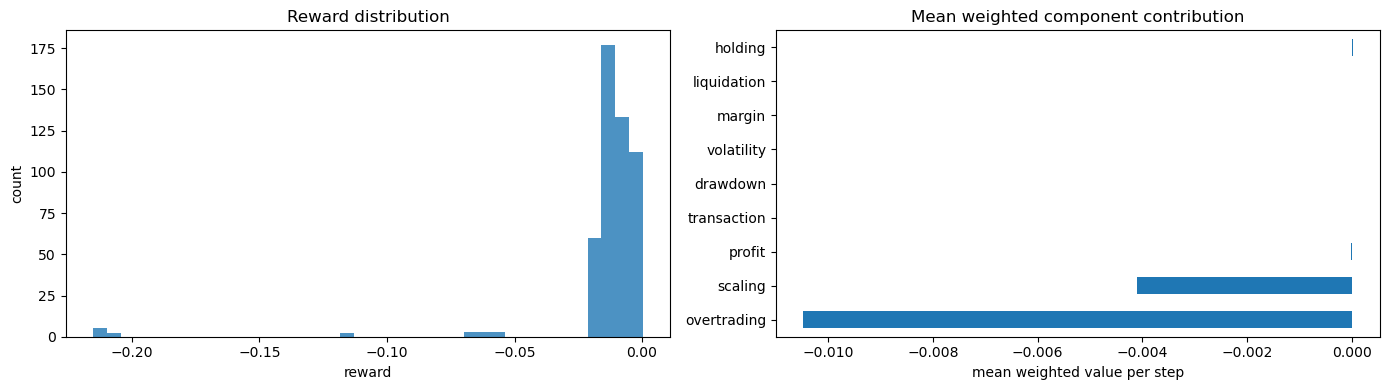

✅ Saved reward diagnostics to C:\Users\Nabeel\Desktop\frl-trading-framework\outputs\experiments\reward_analysis_notebook\summary


In [5]:
from src.utils.artifact_manager import ArtifactManager

env = make_env(test_df, PAIR, CONFIG, reward_engine=reward_engine)
obs, info = env.reset(seed=SEED + 7)

rows = []
component_agg = {}
for t in range(500):
    legal = np.where(obs['mask'] > 0)[0]
    action = int(np.random.choice(legal)) if len(legal) else int(Action.HOLD)
    obs, reward, terminated, truncated, info = env.step(action)
    rb = info.get('reward_breakdown', {})

    row = {'step': t, 'reward': float(reward), 'drawdown': float(info.get('drawdown', 0.0))}
    for k, v in rb.items():
        if isinstance(v, dict) and 'weighted' in v:
            row[f'comp_{k}'] = float(v['weighted'])
            component_agg[k] = component_agg.get(k, 0.0) + float(v['weighted'])
    rows.append(row)

    if terminated or truncated:
        break

reward_df = pd.DataFrame(rows)
display(reward_df.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(reward_df['reward'], bins=40, alpha=0.8)
axes[0].set_title('Reward distribution')
axes[0].set_xlabel('reward')
axes[0].set_ylabel('count')

if component_agg:
    comp_mean = pd.Series(component_agg) / max(len(reward_df), 1)
    comp_mean.sort_values().plot(kind='barh', ax=axes[1])
    axes[1].set_title('Mean weighted component contribution')
    axes[1].set_xlabel('mean weighted value per step')

plt.tight_layout()
plt.show()

am = ArtifactManager(CONFIG.get('paths', {}).get('root', ROOT) + '/outputs')
summary_dir = am.experiment_summary_dir('reward_analysis_notebook')
tables_dir = summary_dir / 'tables'
figures_dir = summary_dir / 'figures'
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

reward_df.to_csv(tables_dir / 'reward_step_diagnostics.csv', index=False)
pd.DataFrame([{'component': k, 'mean_weighted': v / max(len(reward_df), 1)} for k, v in component_agg.items()]).to_csv(
    tables_dir / 'reward_component_means.csv', index=False
)
print(f'✅ Saved reward diagnostics to {summary_dir}')